# étoiles binaires spectroscopiques
$\rightarrow$ **analyse de l'étoile12 Boo (données de Philippe)**

## la cible
- 12 Boo est une étoile binaire spectroscopique de la constellation du Bouvier (mV = 4,83)
- La composante primaire (12 Boo Aa) : F8IV
- La composante secondaire (12 Boo Ab) : F8V 
- 12 Boo est une binaire SB2 (double raie) : leur VR/phase montre deux sinusoïdes qui se croisent.
- Quand les étoiles sont "côte à côte" (vu de la Terre), leurs vitesses sont identiques -> un seul pic.
- Quand elles sont à l'opposé sur leur orbite ->  deux pics distincts.

| **Paramètre** | 	Symbole	 | Valeur Pro | 
| -- | --| -- |
| **Période** | $P$ | **9,6045 j** | 9,6045 j (fixé) |
| **Excentricité** | $e$ | **0,192** | **0,178** (Excellent !) |
| **Vitesse systémique** | $\\gamma$ | **\-10,7 km/s** | **\-9,89 km/s** |
| **Amplitude Étoile A** | $K_A$ | **67,2 km/s** | **73,4 km/s** |
| **Amplitude Étoile B** | $K_B$ | **69,3 km/s** | **75,9 km/s** |
| **Argument périastre** | $\\omega$ | **286°** (sec.) | **190°** (primaire) |

--> **pas facile de détecter et de distinguer les deux pics**

## les données 

|||
|---|---|
|OBJECT|	12_Boo  |
|EXPTIME2|	3 x 600 s|
|BSS_ITRP|	16746|
|BSS_VHEL|	0|
|DATE-OBS|	2025-06-16T23:14:30.305 + ...|
|CDELT1| 0.04877652979666891 |                                                 
|BSS_SITE|	Marcenat|
|BSS_INST|	AP115-800 + StarEx2400 + ASI533MM|
|||
             


In [1]:
# import de base
import os, pathlib, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as imageio

import astropy.units as u
from astropy.io import fits
from astropy.nddata import StdDevUncertainty
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astropy.modeling import models
from astropy.stats import mad_std

from specutils import Spectrum
from specutils.fitting import fit_generic_continuum, fit_continuum
from specutils.analysis import centroid, fwhm, snr, snr_derived
from specutils.spectra import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import correlation

from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import correlate
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter



In [2]:
# 0. Import du dashboard
%matplotlib widget
from spectro_dashboard import SpectroDashboard

# 1. Afficher le dashboard
db = SpectroDashboard()
db.show()


In [4]:
# paramètres connus (pour aider le modèle)

DISP = 0.0487765        # Dispersion StarEx (A/pixel)
LAMBDA_C = 6562.81       # Longueur d'onde centrale (A)
V_PIX = 299792.458 * (DISP / LAMBDA_C) # VR pour un pixel -> 2.22 km/s)
P = 9.591               # Période orbitale de (jours)
T0_REF = 2460844.2      # Date de référence (JD)
K_A = 68.2              # Amplitude étoile A (km/s)
K_B = 70.8              # Amplitude étoile B (km/s)
E_REF = 0.19            # Excentricité de référence
OMEGA_REF = 190         # Argument du périastre (degrés)
GAMMA_REF = -10.5       # Vitesse systémique (km/s)
#OFFSET_INST = 0         # À ajuster selon ta calibration néon
OFFSET_INST = -6.0   # km/s — à affiner après la prochaine itération

# CONFIGURATION & LOCALISATION (Marcenat)
#Latitude : 45,306° N (environ 45° 18' 25'' N)
#Longitude : 2,828° E (environ 2° 49' 36'' E) 

location = EarthLocation(lat=45.306*u.deg, lon=-2.828*u.deg, height=1000*u.m)   
target = SkyCoord.from_name('12 Boo')

# chargement des spectres --> data_list[] et création du GIF animé
files_path = "data/12Boo/_12_boo_202506*.fits"

# plage de recherche et de comparaison avec le template
region_travail = SpectralRegion(6490*u.AA, 6700*u.AA) 
#region_travail = SpectralRegion(6550*u.AA, 6700*u.AA)

# raies générées du spectre synthétique (Fe, Ni, etc...)
synth_lines = [
    #6493.78, 6494.98, 6499.48, #, 6518.37, 6533.93, # Zone bleue
    6456.38, 6481.87, 6493.78, 6494.98, 6499.48,  6518.37, 6517.07, 6546.24,  # Zone bleue
    6562.81,                                     # H alpha
    6633.75, 6643.63, 6663.44, 6678.00, 6696.32  # Zone rouge
]



# chargement des données

In [5]:

files = sorted(glob.glob(files_path))
data_list = []
images = []
temp_file = 'images/temp.png'
gif_file = 'images/12boo_animation.gif'


for f in files:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        spec = Spectrum.read(f)
        
        # Extraction et normalisation 
        spec_sub = extract_region(spec, region_travail)
        #new_flux = (spec_sub.flux.value - np.median(spec_sub.flux.value)) * u.dimensionless_unscaled
        
        #spec_final = Spectrum(flux=new_flux, spectral_axis=spec_sub.spectral_axis)
        spec_final = Spectrum(flux=spec_sub.flux, spectral_axis=spec_sub.spectral_axis)
        jd = float(spec.meta['header']['JD-OBS'])
        data_list.append({'jd': jd, 'spec': spec_final})

        """
        # Création du graphique animé
        plt.figure()
        plt.plot(spec.spectral_axis, spec.flux)
        plt.title(spec.meta['header']['DATE-OBS'])
        plt.ylim(0.3, 1.1)
        plt.xlim(6515, 6700)
        plt.xlabel("Longueur d'onde")
        plt.ylabel("Flux")
        #plt.axvline(x=4861, color='red', linestyle='--', linewidth=1, label='Hbeta')
        plt.legend()
        
        # Sauvegarde temporaire
        plt.savefig(temp_file)
        plt.close()
        
        # Ajout à la liste d'images
        images.append(imageio.imread(temp_file))
        """
        
# Création du GIF
#os.remove(temp_file)
#imageio.imwrite(gif_file, images, duration=500, format='GIF', loop=0)   

#data_list
#[spec['spec'] for spec in data_list]


# génération du 'template'

In [6]:

def generate_synthetic_mask_v0(wavelengths, lines):
    mask = np.ones_like(wavelengths)
        
    for l in lines:
        # On trouve l'index le plus proche et on met 1.0 (un seul pixel)
        #idx = np.abs(wavelengths - l).argmin()
        #mask[idx] = 0.0
        # Ajout des raies (gaussiennes inversées)
        mask -= 0.3 * np.exp(-0.5 * ((wavelengths - l) / 0.1)**2)
        
    return mask

def generate_synthetic_mask(wavelengths, lines):
    mask = np.ones_like(wavelengths)
    sigma_inst = 0.44 / 2.355  # PSF instrumentale à R=15000
    for l in lines:
        mask -= 0.3 * np.exp(-0.5 * ((wavelengths - l) / sigma_inst)**2)
    return mask
    
    
def load_template_v0(fits_path, my_wavelengths):
    spec = Spectrum.read(fits_path)
    #data = np.array(spec.flux.value, dtype=np.float64).flatten()
    data = np.array(spec.flux.value, dtype=np.float64)
        
    # Nettoyage des NaNs 
    #data = np.nan_to_num(data, nan=np.nanmedian(data))

    # --- RECONSTRUCTION AXE X ---
    hdr = spec.meta['header']
    # On force la dispersion linéaire
    x_pro = hdr['CRVAL1'] + np.arange(len(data)) * hdr['CDELT1']

    # --- INTERPOLATION ---
    f_interp = interp1d(x_pro, data, bounds_error=False, fill_value=0)
    template_resampled = f_interp(my_wavelengths)
    
    # On supprime H-alpha du template pour ne garder que les raies fines (métalliques)
    #mask_sans_halpha = template_resampled.copy()
    #mask_sans_halpha[(my_wavelengths > 6545) & (my_wavelengths < 6580)] = 0
    
    #print(f"Somme finale DATA_SIGNAL: {np.nansum(data_norm):.2f}")
    return (template_resampled)

# Dans load_template, après la reconstruction de x_pro,
# recaler sur H-alpha au repos

def load_template(fits_path, my_wavelengths):
    spec = Spectrum.read(fits_path)
    data = np.array(spec.flux.value, dtype=np.float64)
    hdr = spec.meta['header']
    x_pro = hdr['CRVAL1'] + np.arange(len(data)) * hdr['CDELT1']
    
    # Recalage sur H-alpha au repos
    mask_ha = (x_pro > 6555) & (x_pro < 6575)
    ha_center = x_pro[mask_ha][np.argmin(data[mask_ha])]
    ha_rest = 6562.810
    delta_v = (ha_center - ha_rest) / ha_rest * 299792.458  # km/s
    print(f"Template offset H-alpha : {delta_v:.1f} km/s → correction appliquée")
    
    # Décalage de l'axe wavelength du template
    x_pro_corrected = x_pro * (ha_rest / ha_center)
    
    f_interp = interp1d(x_pro_corrected, data, bounds_error=False, fill_value=0)
    return f_interp(my_wavelengths)
    

INFO: affichage du spectre 'F8IV' : 104413 pts, X:[3773.4:9005.2]
Template offset H-alpha : -14.2 km/s → correction appliquée


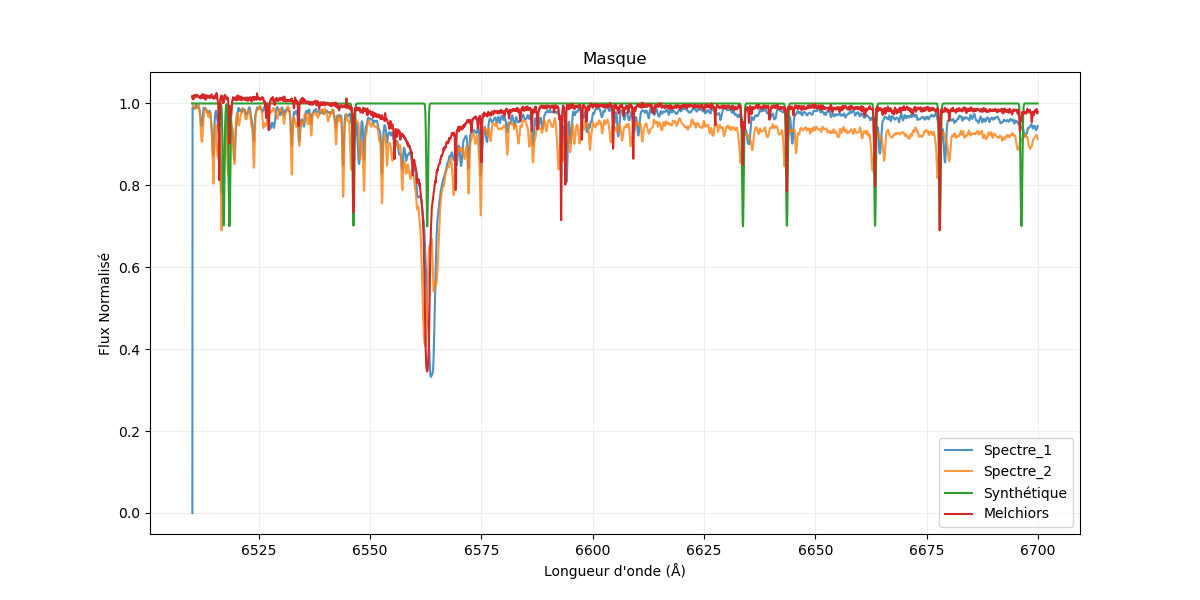

In [7]:

spec_name = "data/12Boo/F8IV_melchiors_417802.fits"
spec = Spectrum.read(spec_name)
db.show_spectrum(spec.spectral_axis, spec.flux, label='F8IV')


# On récupère les données de deux spectres
entry_test = data_list[6]
wave_obs = entry_test['spec'].wavelength.value
flux_obs = entry_test['spec'].flux.value

melchiors_flux = load_template('data/12Boo/F8IV_melchiors_417802.fits', wave_obs)
mask_flux = generate_synthetic_mask(wave_obs, synth_lines)

# On vérifie visuellement que le masque permet de repérer des raies du spectres NON TELLURIQUES !
plt.figure(figsize=(12, 6))
plt.plot(data_list[3]['spec'].wavelength.value, data_list[3]['spec'].flux.value / np.max(data_list[3]['spec'].flux.value), label='Spectre_1', alpha=0.8)
plt.plot(data_list[6]['spec'].wavelength.value, data_list[6]['spec'].flux.value / np.max(data_list[6]['spec'].flux.value), label='Spectre_2', alpha=0.8)
plt.plot(wave_obs, mask_flux, label='Synthétique', lw=1.5) #, ls='--')
plt.plot(wave_obs, melchiors_flux+0.2, label='Melchiors', lw=1.5) #, ls='--')

plt.title(f"Masque")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux Normalisé")
plt.legend()
#plt.xlim(6450, 6700)
#plt.ylim(0.4, 1.1)
plt.grid(alpha=0.2)
plt.show()

# analyse - méthode BF


In [8]:
def get_barycentric_correction(jd_utc):
    """Correction de la vitesse de la Terre (Rennes -> 12 Boo)"""
    t = Time(jd_utc, format='jd', scale='utc')
    vcorr = target.radial_velocity_correction(kind='barycentric', obstime=t, location=location)
    return vcorr.to(u.km / u.s)

def compute_broadening_function(observed_flux, template_flux, vel_width=150):
    """
    Calcule la Broadening Function (BF) par Décomposition en Valeurs Singulières (SVD).
    
    Args:
        observed_flux: Spectre de l'étoile (normalisé)
        template_flux: Masque synthétique (normalisé)
        vel_width: Largeur de la fenêtre de recherche en pixels
        
    Returns:
        v_axis: Axe des vitesses en km/s
        bf: Intensité de la BF
    """
    # Synchronisation des tailles et centrage
    n = min(len(observed_flux), len(template_flux))
    o = observed_flux[:n] - np.mean(observed_flux[:n])
    t = template_flux[:n] - np.mean(template_flux[:n])
    
    # Construction de la matrice de design (M)
    m = 2 * vel_width + 1
    M = np.zeros((n, m))
    for i in range(m):
        M[:, i] = np.roll(t, i - vel_width)
    
    # Résolution SVD et filtrage du bruit
    U, S, Vh = svd(M, full_matrices=False)
    S_inv = np.where(S > 0.05 * np.max(S), 1/S, 0) # Seuil de troncature
    
    # Reconstruction
    bf = Vh.T @ np.diag(S_inv) @ U.T @ o
    v_axis = (np.arange(m) - vel_width) * V_PIX
    
    return v_axis, bf

# =============================================================================
# 3. MODÉLISATION ORBITALE
# =============================================================================

def solve_kepler(M, e, tol=1e-10):
    e = np.clip(e, 0.0, 0.9999)  # ← évite e≥1 pendant l'optimisation
    E = M.copy() if hasattr(M, 'copy') else np.array([M])
    for _ in range(50):
        dE = (M - E + e * np.sin(E)) / (1 - e * np.cos(E))
        E += dE
        if np.max(np.abs(dE)) < tol:
            break
    return E

def rv_kepler(t, t0, P, K, e, omega_deg, gamma):
    """
    VR keplerienne exacte.
    t, t0 : JD
    K     : demi-amplitude km/s (toujours positif)
    omega : argument du périastre de l'étoile (degrés)
    """
    t = np.atleast_1d(np.array(t, dtype=float))
    omega = np.radians(omega_deg)
    M = 2 * np.pi * ((t - t0) % P) / P
    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2),
        np.sqrt(1 - e) * np.cos(E / 2)
    )
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def rv_kepler_scalar(t, t0, P, K, e, omega_deg, gamma):
    """Version scalaire pour curve_fit."""
    return rv_kepler(np.atleast_1d(t), t0, P, K, e, omega_deg, gamma)

def fit_rv_curve(jd_arr, vr_arr, P_fixed, is_star_b=False):
    """
    Fit keplérien exact. P est fixé, 5 paramètres libres : t0, K, e, omega, gamma.
    """
    # Nettoyage des NaN
    good = ~np.isnan(vr_arr)
    jd_fit, vr_fit = jd_arr[good], vr_arr[good]
    
    if len(jd_fit) < 5:
        raise ValueError(f"Pas assez de points : {len(jd_fit)}")

    # Valeurs initiales
    omega0 = 190.0 if not is_star_b else 10.0   # omega_B = omega_A + 180°
    p0 = [T0_REF, 70.0, 0.19, omega0, -11.0]
    
    # Bornes
    bl = [T0_REF - P_fixed, 40.0, 0.05, omega0 - 80, -25.0]
    bh = [T0_REF + P_fixed, 110.0, 0.35, omega0 + 80,   5.0]
    
    def model(t, t0, K, e, omega, gamma):
        return rv_kepler_scalar(t, t0, P_fixed, K, e, omega, gamma)
    
    popt, pcov = curve_fit(
        model, jd_fit, vr_fit,
        p0=p0, bounds=(bl, bh),
        max_nfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

def calculate_masses(K_A, K_B, period_days, eccentricity):
    G = 6.67430e-11
    P_sec = period_days * 86400
    ka_ms = abs(K_A) * 1000
    kb_ms = abs(K_B) * 1000
    factor = (P_sec / (2 * np.pi * G)) * (1 - eccentricity**2)**1.5
    ma = factor * (ka_ms + kb_ms)**2 * kb_ms / 1.98847e30
    mb = factor * (ka_ms + kb_ms)**2 * ka_ms / 1.98847e30
    return ma, mb
    

In [9]:
from scipy.optimize import curve_fit

def rotational_profile(v, v0, amp, vsini, epsilon=0.6):
    """
    Profil d'élargissement rotationnel de Gray (1992).
    epsilon : coefficient de brunissement aux bords (limb darkening)
    """
    x = (v - v0) / vsini
    mask = np.abs(x) < 1.0
    profile = np.zeros_like(v)
    profile[mask] = amp * (
        2 * (1 - epsilon) * np.sqrt(1 - x[mask]**2)
        + 0.5 * np.pi * epsilon * (1 - x[mask]**2)
    ) / (np.pi * vsini * (1 - epsilon/3))
    return profile

def double_rotational_profile(v, v0a, ampa, vsinia, v0b, ampb, vsinib):
    return rotational_profile(v, v0a, ampa, vsinia) + \
           rotational_profile(v, v0b, ampb, vsinib)

def fit_bf_peaks(v_axis, bf, v_target_a, v_target_b, vsini_init=15.0):
    """
    Ajuste deux profils rotationnels sur la BF.
    Retourne (va, vb) ou (nan, nan) si le fit échoue.
    """
    # Fenêtre de recherche élargie autour des cibles théoriques
    #search_half = 60  # km/s
    search_half = 80  # élargi de 60 à 80 km/s
    threshold_pcov = 30  # élargi de 20 à 30 km/s

    
    # Estimation initiale de l'amplitude : max de la BF près de chaque cible
    def peak_amp_near(vtarget):
        idx = np.abs(v_axis - vtarget) < search_half
        if not idx.any():
            return np.max(bf) * 0.5
        return np.max(bf[idx])
    
    amp_a0 = peak_amp_near(v_target_a)
    amp_b0 = peak_amp_near(v_target_b)
    
    separation = abs(v_target_a - v_target_b)
    
    if separation < 25:
        # Conjonction : pics fusionnés, on ajuste un seul profil
        try:
            p0 = [(v_target_a + v_target_b) / 2, (amp_a0 + amp_b0) / 2, vsini_init]
            """
            bounds = (
                [min(v_target_a, v_target_b) - 40, 0, 5],
                [max(v_target_a, v_target_b) + 40, np.max(bf) * 2, 60]
            )
            """
            bounds = (
                [v_target_a - search_half, 0, 8],
                [v_target_a + search_half, np.max(bf) * 2, 80]
            )
            popt, _ = curve_fit(
                lambda v, v0, amp, vs: rotational_profile(v, v0, amp, vs),
                v_axis, bf, p0=p0, bounds=bounds, maxfev=2000
            )
            return popt[0], np.nan  # on attribue à A, B inconnu
        except Exception:
            return np.nan, np.nan
    else:
        # Séparation suffisante : fit double
        try:
            p0 = [v_target_a, amp_a0, vsini_init,
                  v_target_b, amp_b0, vsini_init]
            bounds = (
                [v_target_a - search_half, 0, 5,
                 v_target_b - search_half, 0, 5],
                [v_target_a + search_half, np.max(bf) * 2, 60,
                 v_target_b + search_half, np.max(bf) * 2, 60]
            )
            popt, pcov = curve_fit(
                double_rotational_profile,
                v_axis, bf, p0=p0, bounds=bounds, maxfev=5000
            )
            # Vérification qualité : écart-type des paramètres
            perr = np.sqrt(np.diag(pcov))
            va = popt[0] if perr[0] < 20 else np.nan
            vb = popt[3] if perr[3] < 20 else np.nan
            return va, vb
        except Exception:
            # Fallback : un seul profil sur le pic dominant
            try:
                i_max = np.argmax(bf)
                p0 = [v_axis[i_max], np.max(bf), vsini_init]
                popt, _ = curve_fit(
                    lambda v, v0, amp, vs: rotational_profile(v, v0, amp, vs),
                    v_axis, bf, p0=p0, maxfev=1000
                )
                # Attribuer au plus proche des deux cibles
                if abs(popt[0] - v_target_a) < abs(popt[0] - v_target_b):
                    return popt[0], np.nan
                else:
                    return np.nan, popt[0]
            except Exception:
                return np.nan, np.nan


def fit_rv_curve(jd_arr, vr_arr, P_fixed, is_star_b=False):
    jd_arr = np.array(jd_arr, dtype=float)
    vr_arr = np.array(vr_arr, dtype=float)
    
    # Étape 1 : filtre NaN/inf
    good = np.isfinite(vr_arr)
    jd_fit, vr_fit = jd_arr[good], vr_arr[good]
    
    # Étape 2 : rejet des outliers (> 2.5 MAD de la médiane)
    median_v = np.median(vr_fit)
    mad = np.median(np.abs(vr_fit - median_v))
    inliers = np.abs(vr_fit - median_v) < 2.5 * mad + 20  # +20 km/s marge
    jd_fit, vr_fit = jd_fit[inliers], vr_fit[inliers]
    
    if len(jd_fit) < 5:
        raise ValueError(f"Pas assez de points après nettoyage : {len(jd_fit)}")
    
    print(f"  {'B' if is_star_b else 'A'} : {len(jd_fit)} points utilisés sur {good.sum()}")
    
    omega0 = 190.0 if not is_star_b else 10.0
    p0 = [T0_REF, 70.0, 0.19, omega0, -11.0]
    bl = [T0_REF - P_fixed, 40.0, 0.05, omega0 - 80, -25.0]
    bh = [T0_REF + P_fixed, 110.0, 0.35, omega0 + 80,   5.0]
    
    def model(t, t0, K, e, omega, gamma):
        return rv_kepler_scalar(t, t0, P_fixed, K, e, omega, gamma)
    
    popt, pcov = curve_fit(
        model, jd_fit, vr_fit,
        p0=p0, bounds=(bl, bh),
        max_nfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

Template offset H-alpha : -14.2 km/s → correction appliquée

JD             | φ      | VR_A (km/s)   | VR_B (km/s)   | sep (km/s)
----------------------------------------------------------------------
2460843.46841  | 0.924 |      -49.40  |       64.53  | 146.4
2460844.43400  | 0.024 |      -68.34  |       77.62  | 153.9
2460845.40259  | 0.125 |      -38.35  |       53.33  | 66.1
2460846.40154  | 0.229 |       23.10  |       -5.41  | 31.1
2460847.40213  | 0.333 |        1.77  |      -80.73  | 90.1
2460848.39672  | 0.437 |       53.27  |      -35.12  | 112.3
2460849.41439  | 0.543 |       66.13  |      -49.84  | 104.0
2460850.39917  | 0.645 |       20.14  |      -55.69  | 67.9
2460851.37702  | 0.747 |      -35.57  |         nan  | 3.3
2460853.40556  | 0.958 |      -66.99  |       75.38  | 161.9
2460854.42253  | 0.064 |      -68.15  |       67.82  | 126.0
2460855.39118  | 0.165 |         nan  |         nan  | 25.3
2460856.40122  | 0.270 |       -4.68  |        6.26  | 59.3


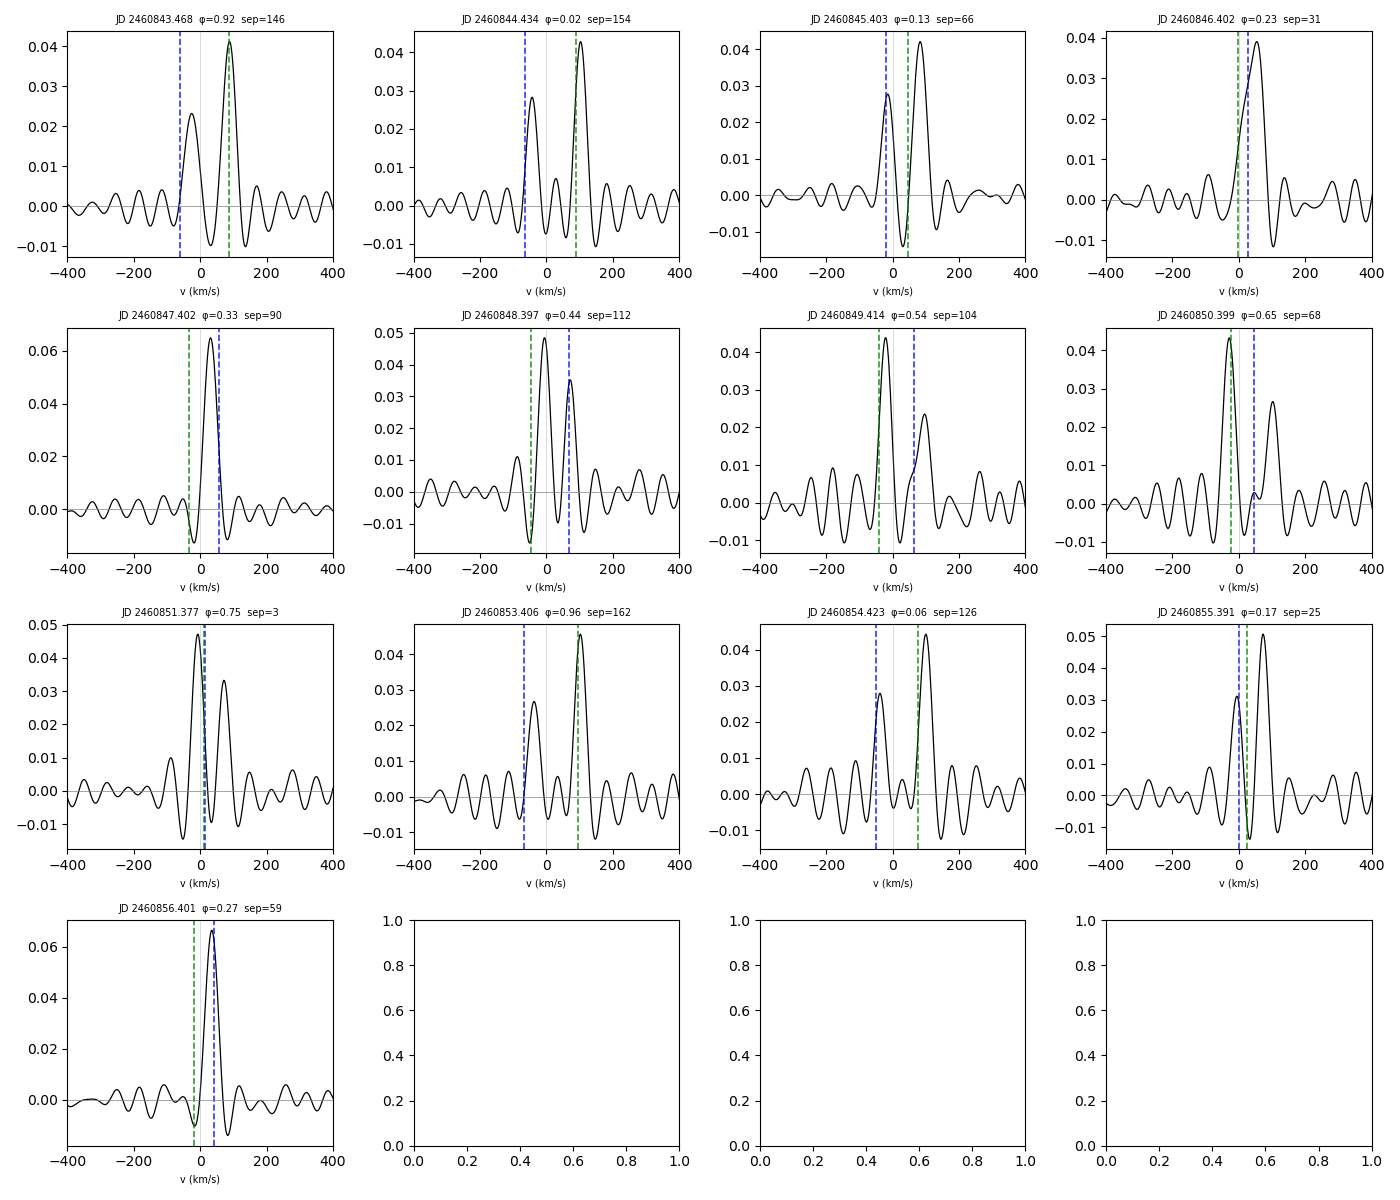

  A : 12 points utilisés sur 12
  B : 11 points utilisés sur 11

Vérification : omega_B - omega_A = 253.8° (attendu ~180°)


/var/folders/r1/s24q5jr91lgb5xgp830lvyj80000gn/T/ipykernel_78356/1257469997.py:68: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(1 - e) * np.cos(E / 2)


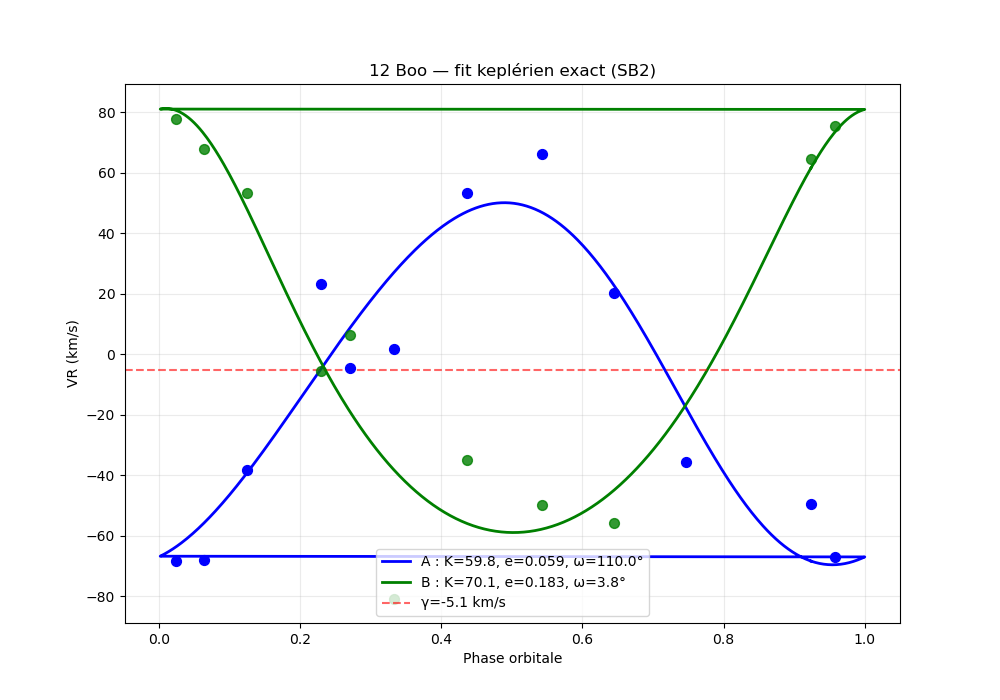


PARAMÈTRES ORBITAUX (fit keplérien exact)
Période fixée   P   = 9.6045 j
Excentricité    e   = 0.121  (A:0.059 / B:0.183)
Vit. systémique γ   = -5.10 km/s
Demi-amplitude  K_A = 59.83 ± 8.45 km/s
Demi-amplitude  K_B = 70.07 ± 8.99 km/s
Arg. périastre  ω_A = 110.0°  ω_B = 3.8°  Δ=253.8°
T0 (périastre)  t0  = 2460842.0595 JD
----------------------------------------
M_A sin³i = 1.151 M☉
M_B sin³i = 0.983 M☉


In [15]:
from scipy.ndimage import gaussian_filter1d
# ============================================================
# CHARGEMENT TEMPLATE 
# ============================================================
wave_ref = data_list[0]['spec'].wavelength.value
melchiors_raw = load_template('data/12Boo/F8IV_melchiors_417802.fits', wave_ref)
melchiors_norm = melchiors_raw / np.percentile(melchiors_raw, 95) - 1.0
sigma_px = (0.44 / 2.355) / DISP
melchiors_conv = gaussian_filter1d(melchiors_norm, sigma=sigma_px)
mask_template = -melchiors_conv   # raies positives pour SVD

# ============================================================
# BOUCLE BF
# ============================================================
results_A, results_B, jd_list, phases = [], [], [], []

print(f"\n{'JD':<14} | {'φ':<6} | {'VR_A (km/s)':<13} | {'VR_B (km/s)':<13} | {'sep (km/s)'}")
print("-" * 70)

fig_bf, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

for i, entry in enumerate(data_list):
    wave = entry['spec'].wavelength.value
    flux_raw = entry['spec'].flux.value
    jd = entry['jd']

    # Normalisation
    obs_flux = flux_raw / np.percentile(flux_raw, 95) - 1.0

    # Template interpolé sur la grille courante si nécessaire
    if not np.array_equal(wave, wave_ref):
        f_interp = interp1d(wave_ref, mask_template, bounds_error=False, fill_value=0)
        mask_flux = f_interp(wave)
    else:
        mask_flux = mask_template

    # BF
    v_axis, bf = compute_broadening_function(obs_flux, mask_flux, vel_width=200)
    bf = -bf

    # Correction barycentrique
    v_bary = get_barycentric_correction(jd).value

    # Phase et cibles théoriques (kepler exact avec params de référence)
    ph = ((jd - T0_REF) % P) / P
    
    # Cibles dans le référentiel BF (avant correction barycentrique)
    vta_bfref = rv_kepler(jd, T0_REF, P, K_A, E_REF, OMEGA_REF, GAMMA_REF)[0] - v_bary
    vtb_bfref = rv_kepler(jd, T0_REF, P, K_B, E_REF, OMEGA_REF + 180, GAMMA_REF)[0] - v_bary
    sep = abs(vta_bfref - vtb_bfref)

    # Fit double profil
    va, vb = fit_bf_peaks(v_axis, bf, vta_bfref, vtb_bfref)

    # Correction barycentrique + offset instrumental
    if not np.isnan(va):
        va += v_bary + OFFSET_INST
    if not np.isnan(vb):
        vb += v_bary + OFFSET_INST

    print(f"{jd:.5f}  | {ph:.3f} | {va:11.2f}  | {vb:11.2f}  | {sep:.1f}")

    results_A.append(va)
    results_B.append(vb)
    jd_list.append(jd)
    phases.append(ph)

    # Plot diagnostic individuel
    if i < len(axes):
        ax = axes[i]
        ax.plot(v_axis, bf, 'k-', lw=0.9)
        ax.axvline(vta_bfref, color='blue',  lw=1.2, ls='--', alpha=0.8)
        ax.axvline(vtb_bfref, color='green', lw=1.2, ls='--', alpha=0.8)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlim(-200, 200)
        ax.set_title(f"JD {jd:.3f}  φ={ph:.2f}  sep={sep:.0f}", fontsize=7)
        ax.set_xlabel('v (km/s)', fontsize=7)
        ax.set_xlim(-400, 400)

plt.tight_layout()
plt.savefig('images/bf_individual.png', dpi=120)
plt.show()

# ============================================================
# FIT ORBITAL KEPLER EXACT
# ============================================================
jd_arr      = np.array(jd_list)
results_A_np = np.array(results_A)
results_B_np = np.array(results_B)
phases_np    = np.array(phases)

try:
    popt_A, perr_A = fit_rv_curve(jd_arr, results_A_np, P_fixed=P, is_star_b=False)
    popt_B, perr_B = fit_rv_curve(jd_arr, results_B_np, P_fixed=P, is_star_b=True)
except ValueError as err:
    print(f"Fit impossible : {err}")
    raise

t0_A, K_A_fit, e_A, omega_A, gamma_A = popt_A
t0_B, K_B_fit, e_B, omega_B, gamma_B = popt_B

# Vérification cohérence omega
delta_omega = (omega_B - omega_A) % 360
print(f"\nVérification : omega_B - omega_A = {delta_omega:.1f}° (attendu ~180°)")

# Courbes modèles sur grille temporelle fine
t_plot = np.linspace(jd_arr.min(), jd_arr.min() + P, 500)
ph_plot = ((t_plot - T0_REF) % P) / P
v_A_plot = rv_kepler(t_plot, *popt_A, P)
v_B_plot = rv_kepler(t_plot, *popt_B, P)

# Correction : rv_kepler prend (t, t0, P, K, e, omega, gamma)
v_A_plot = rv_kepler(t_plot, popt_A[0], P, popt_A[1], popt_A[2], popt_A[3], popt_A[4])
v_B_plot = rv_kepler(t_plot, popt_B[0], P, popt_B[1], popt_B[2], popt_B[3], popt_B[4])

mask_a = ~np.isnan(results_A_np)
mask_b = ~np.isnan(results_B_np)

plt.figure(figsize=(10, 7))
plt.plot(ph_plot, v_A_plot, 'b-', lw=2, label=f'A : K={K_A_fit:.1f}, e={e_A:.3f}, ω={omega_A:.1f}°')
plt.plot(ph_plot, v_B_plot, 'g-', lw=2, label=f'B : K={K_B_fit:.1f}, e={e_B:.3f}, ω={omega_B:.1f}°')
plt.axhline((gamma_A + gamma_B) / 2, color='red', ls='--', alpha=0.6, label=f'γ={((gamma_A+gamma_B)/2):.1f} km/s')
plt.scatter(phases_np[mask_a], results_A_np[mask_a], color='blue',  s=50, zorder=3)
plt.scatter(phases_np[mask_b], results_B_np[mask_b], color='green', s=50, zorder=3, alpha=0.8)
plt.xlabel('Phase orbitale')
plt.ylabel('VR (km/s)')
plt.title('12 Boo — fit keplérien (SB2)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ============================================================
# RÉSULTATS FINAUX
# ============================================================
ma, mb = calculate_masses(K_A_fit, K_B_fit, P, (e_A + e_B) / 2)
e_mean = (e_A + e_B) / 2
gamma_mean = (gamma_A + gamma_B) / 2

print("\n" + "=" * 40)
print("PARAMÈTRES ORBITAUX (fit keplérien)")
print("=" * 40)
print(f"Période fixée   P   = {P:.4f} j")
print(f"Excentricité    e   = {e_mean:.3f}  (A:{e_A:.3f} / B:{e_B:.3f})")
print(f"Vit. systémique γ   = {gamma_mean:.2f} km/s")
print(f"Demi-amplitude  K_A = {K_A_fit:.2f} ± {perr_A[1]:.2f} km/s")
print(f"Demi-amplitude  K_B = {K_B_fit:.2f} ± {perr_B[1]:.2f} km/s")
print(f"Arg. périastre  ω_A = {omega_A:.1f}°  ω_B = {omega_B:.1f}°  Δ={delta_omega:.1f}°")
print(f"T0 (périastre)  t0  = {t0_A:.4f} JD")
print("-" * 40)
print(f"M_A sin³i = {ma:.3f} M☉")
print(f"M_B sin³i = {mb:.3f} M☉")
print("=" * 40)

# analyse - méthode CCF


JD           | VR_Abs (km/s)
----------------------------------------
2460843.46841 |      64.60
2460844.43400 |      79.57
2460845.40259 |      60.38
2460846.40154 |      29.98
2460847.40213 |       7.75
2460848.39672 |     -28.58
2460849.41439 |     -46.25
2460850.39917 |     -52.25
2460851.37702 |     -30.99
2460853.40556 |      78.68
2460854.42253 |      75.82
2460855.39118 |      47.85
2460856.40122 |      10.49


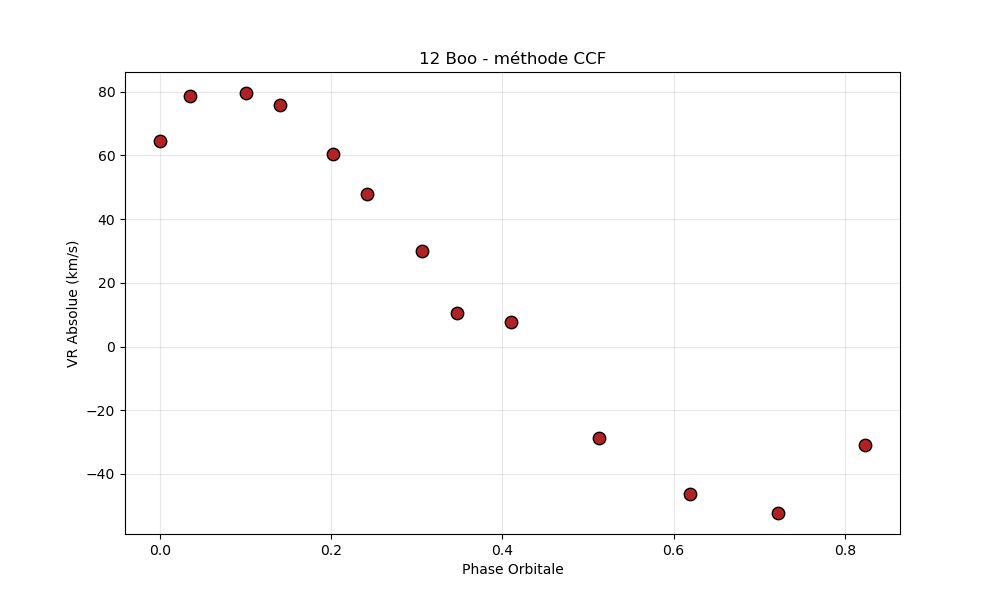

In [12]:
def find_precise_peak(lag, corr):
    """Ajuste une parabole sur le sommet pour une précision sub-pixel"""
    i_max = np.argmax(corr)
    if i_max <= 0 or i_max >= len(corr) - 1:
        return lag[i_max].value
    x = lag[i_max-1 : i_max+2].value
    y = corr[i_max-1 : i_max+2]
    f = np.polyfit(x, y, 2)
    return -f[1] / (2 * f[0])

wave_obs = data_list[0]['spec'].spectral_axis.value

flux_model = generate_synthetic_mask(wave_obs, synth_lines)
tspec_model = Spectrum(flux=flux_model * u.dimensionless_unscaled,
                       spectral_axis=wave_obs * u.AA)


# ---------------------------------------------------------
results = []
print(f"\n{'JD':<12} | {'VR_Abs (km/s)':<12}")
print("-" * 40)


for i, entry in enumerate(data_list):
    
    # On normalise et on retire la moyenne (pour que le continuum soit à 0)
    obs_flux = entry['spec'].flux.value
    obs_flux = obs_flux / np.percentile(obs_flux, 95) - 1.0 
    
    spec_to_corr = Spectrum(flux=obs_flux * u.dimensionless_unscaled,
                            spectral_axis=entry['spec'].spectral_axis)
    
    # Corrélation avec le masque théorique
    #corr, lag = correlation.template_correlate(spec_to_corr, tspec_model)
    corr, lag = correlation.template_correlate(1.0 - entry['spec'], 1.0 - tspec_model)
    #print(f"Décalage min/max du lag : {lag.min()} / {lag.max()}")
    
    v_rel = find_precise_peak(lag, corr)
    v_bary = get_barycentric_correction(entry['jd']).value
    vr_abs = v_rel + v_bary
    
    results.append({'jd': entry['jd'], 'vr': vr_abs})
    print(f"{entry['jd']:.5f} | {vr_abs:10.2f}")

# 6. GRAPHIQUE FINAL (COURBE DE PHASE)
# ---------------------------------------------------------
jd_arr = np.array([r['jd'] for r in results])
vr_arr = np.array([r['vr'] for r in results])

P = 9.6045 
T0 = jd_arr[0]
phases = ((jd_arr - T0) % P) / P

plt.figure(figsize=(10, 6))
plt.scatter(phases, vr_arr, color='firebrick', s=80, edgecolors='k', zorder=3)
#plt.axhline(-10.5, color='gray', linestyle='--', label='Vitesse systémique')
plt.title("12 Boo - méthode CCF")
plt.xlabel("Phase Orbitale")
plt.ylabel("VR Absolue (km/s)")
plt.grid(alpha=0.3)
plt.show()
